In [60]:
import os
import sys
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

# Resolve repository root so this notebook can run from any working directory.
root = Path.cwd().resolve()
while not (root / "wireless_channel").exists() and root != root.parent:
    root = root.parent

if not (root / "wireless_channel").exists():
    raise RuntimeError("Could not locate repository root containing 'wireless_channel'.")

os.chdir(root)
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from plotter import plotter
from sub_THz_stripe.amplifier.amplifier import Amplifier
from sub_THz_stripe.central_unit.central_unit import CentralUnit
from sub_THz_stripe.combiner.combiner import Combiner
from sub_THz_stripe.coupler.coupler import Coupler
from sub_THz_stripe.phase_shifter.phase_shifter import PhaseShifter
from sub_THz_stripe.radio_unit.radio_unit import RadioUnit
from sub_THz_stripe.radiostripe.radiostripe import RadioStripe
from sub_THz_stripe.splitter.splitter import Splitter
from wireless_channel.subTHz_channel import build_channel
from wireless_channel.waveforms import Waveform

print(f"Repository root: {root}")

Repository root: /home/dramco_spark/6GTandem-simulator


In [61]:
# --- User-configurable knobs ---
num_stripes = 2
num_rus_per_stripe = 20
ue_pos_dict = {'x': 2.0, 'y': 2.5, 'z': 1.5}#{'x': 2.0, 'y': 5.0, 'z': 1.5}
ue_position_index = 940
plot_room = True
channel_model = "los"  # "sionna" or "los"
los_normalize_gain = False
plot_wireless_channel = True
plot_channel_stripe_idx = 0
plot_channel_ru_idx = 0
plot_channel_rx_ant_idx = 0
plot_channel_tx_ant_idx = 0

# --- Tutorial-local config files ---
environment = "office_space_perpendicular"
config_dir = root / "examples" / "training_school" / "configs"
#env_config_path = config_dir / "tutorial_environment.yaml" # for tutorial
env_config_path = root / "environments" / environment / "config.yaml" # for sionna debugging
waveform_config_path = config_dir / "tutorial_waveform_config.yaml"
component_config_path = config_dir / "tutorial_component_config.yaml"

with open(env_config_path, "r", encoding="utf8") as file:
    env_config = yaml.safe_load(file)

with open(waveform_config_path, "r", encoding="utf8") as file:
    waveform_config = yaml.safe_load(file)

with open(component_config_path, "r", encoding="utf8") as file:
    component_config = yaml.safe_load(file)


def truncate_radio_stripes(radio_stripes, n_stripes, n_rus):
    """Keep only first n_stripes and first n_rus RUs per stripe."""
    trimmed = []
    for stripe in radio_stripes[:n_stripes]:
        central_units = [entry for entry in stripe if "central_unit" in entry]
        rus = [entry for entry in stripe if "radio_unit" in entry][:n_rus]
        trimmed.append(central_units[:1] + rus)
    return trimmed


selected_stripes_cfg = truncate_radio_stripes(
    env_config["radio_stripes"],
    n_stripes=num_stripes,
    n_rus=num_rus_per_stripe,
)

# Build a dynamic plotting config that matches the selected topology.
# plot_room() uses room, radio_stripes, and ue_positions.
config = deepcopy(env_config)
config["radio_stripes"] = selected_stripes_cfg
if channel_model == "sionna":
    config["ue_positions"] = [env_config["ue_positions"][ue_position_index]]  # Sionna channel builder only supports one UE position.
else: 
    config["ue_positions"] = [ue_pos_dict]


# Keep stripe metadata aligned with the selected subset when available.
if "stripe_config" in config:
    config["stripe_config"]["N_stripes"] = len(selected_stripes_cfg)
    config["stripe_config"]["N_RUs"] = len(selected_stripes_cfg[0]) - 1

print(f"Environment config: {env_config_path.name}")
print(f"Using {len(config['radio_stripes'])} stripes, each with {len(config['radio_stripes'][0]) - 1} RUs")
if channel_model == "sionna":
    print(f"UE position: {config['ue_positions']}")
else:       
    print(f"Plotting UE at: {config['ue_positions'][0]}")
print(f"Channel model: {channel_model}")
print(f"Plot wireless channel: {plot_wireless_channel}")

Environment config: config.yaml
Using 2 stripes, each with 20 RUs
Plotting UE at: {'x': 2.0, 'y': 2.5, 'z': 1.5}
Channel model: los
Plot wireless channel: True


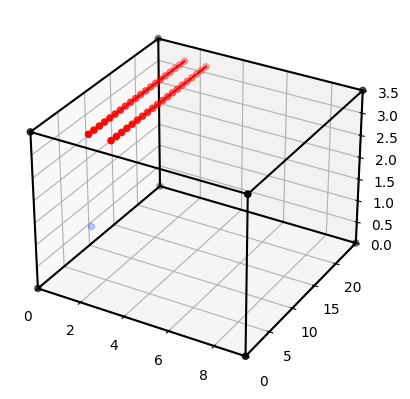

In [62]:
# Plot the room using the dynamically adjusted config.
if plot_room:
    plotter.plot_room(config)
    plt.show()

## generate the signal


In [63]:
# Construct the waveform class based on the loaded configuration.
freq_band_config = config["sub_thz"]
wf = Waveform.from_config(waveform_config, freq_band_config)

In [64]:
# Generate an CP-OFDM waveform in the time domain.
bits = wf.generate_bits()
qam = wf.qam_modulate()
ofdm_time = wf.ofdm_modulate()  # shape: nr_ofdm_symb x (fftsize + cp length)
x_combined_freq = wf.ofdm_time_to_freq(ofdm_time)
xsubc = wf.extract_subcarriers(x_combined_freq)

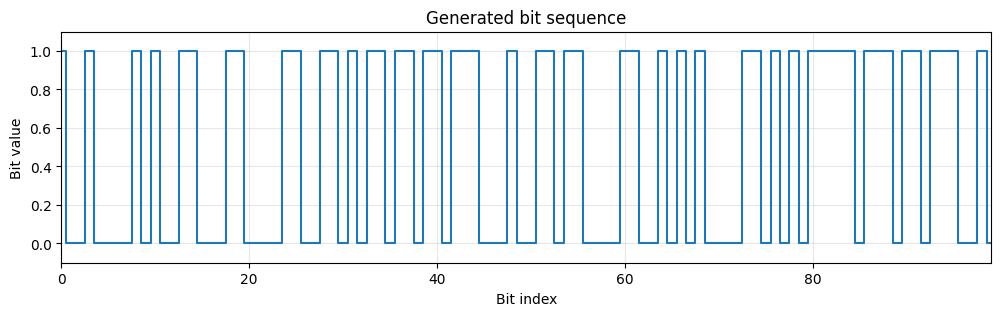

In [65]:
# Plot generated bits
num_bits_to_plot = 100
plt.figure(figsize=(12, 3))
plt.step(np.arange(num_bits_to_plot), bits[:num_bits_to_plot], where="mid")
plt.ylim(-0.1, 1.1)
plt.xlim(0, num_bits_to_plot - 1)
plt.xlabel("Bit index")
plt.ylabel("Bit value")
plt.title("Generated bit sequence")
plt.grid(True, alpha=0.3)
plt.show()

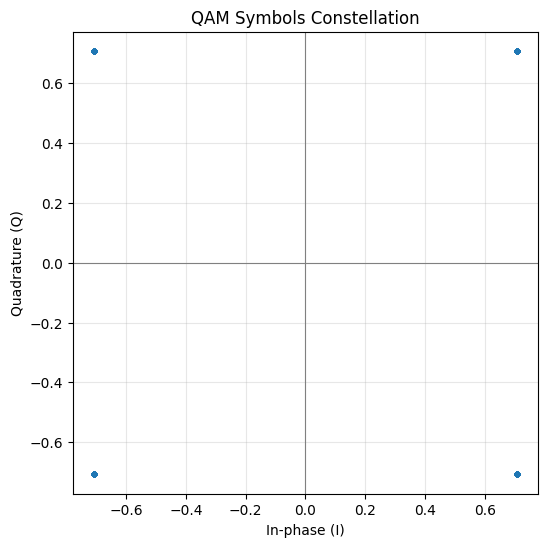

In [66]:
# Plot QAM constellation
plt.figure(figsize=(6, 6))
plt.scatter(qam.real, qam.imag, s=10, alpha=0.7)
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.title("QAM Symbols Constellation")
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.show()

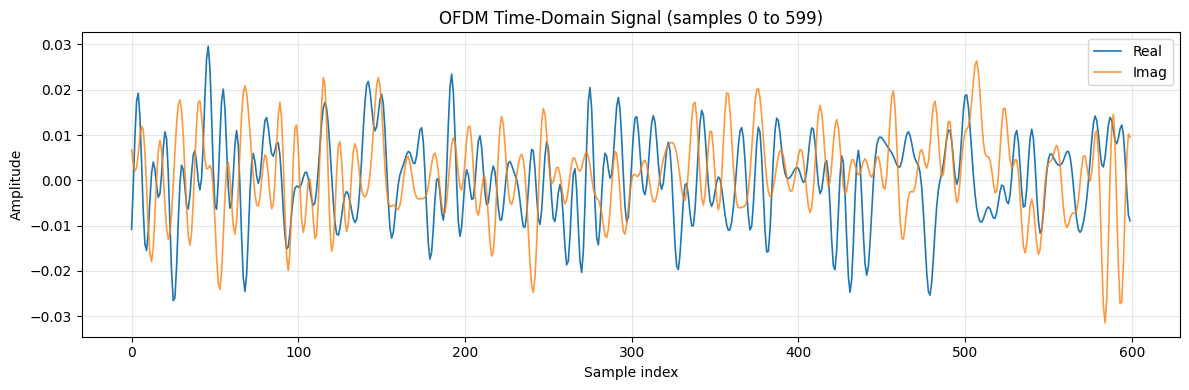

In [67]:
# Plot a portion of the OFDM time-domain signal (first OFDM symbol)
num_samples_to_plot = 600
start_idx = 0
end_idx = min(start_idx + num_samples_to_plot, ofdm_time.shape[-1])

ofdm_symbol = ofdm_time[0]  # first OFDM symbol
n = np.arange(start_idx, end_idx)

plt.figure(figsize=(12, 4))
plt.plot(n, ofdm_symbol[start_idx:end_idx].real, label="Real", linewidth=1.2)
plt.plot(n, ofdm_symbol[start_idx:end_idx].imag, label="Imag", linewidth=1.2, alpha=0.8)
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.title(f"OFDM Time-Domain Signal (samples {start_idx} to {end_idx-1})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

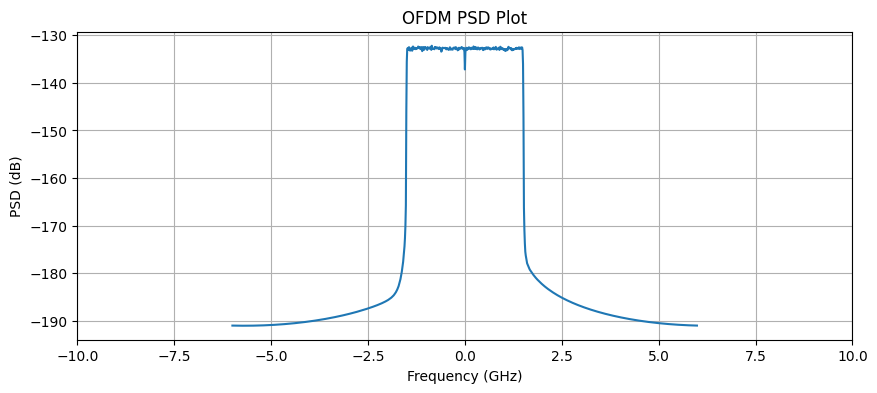

In [68]:
# Plot PSD of the generated OFDM time-domain signal using the waveform helper.
ofdm_signal = ofdm_time.reshape(-1)  # flatten (n_symbols, n_samples) -> 1D
wf.plot_psd(ofdm_signal)
plt.show()

## Generate user and send uplink signal

This section now supports two channel construction paths:

- `channel_model = "sionna"` uses the existing Sionna ray-traced dataset loader.
- `channel_model = "los"` uses the new deterministic line-of-sight OFDM channel.
- The legacy call `Channel.from_sionna(ue_pos, environment, debug=True)` still works unchanged if you want to use it directly.

In [69]:
# The UE has the same hardware as a central unit.
ue = CentralUnit()  # todo are these configs loadable?
ofdm_time_after_ue = ue.run(ofdm_time)  # shape: nr_ofdm_symbols x (fft_size + cp length)

# A single radio unit is used to represent the transmit stage of the ue. The UE position does not influence the
# transmission so we can set it arbitrarily.
amp = Amplifier(bw=config["sub_thz"]["bw"])
coup = Coupler(wf=wf)
split = Splitter(config["antenna"]["N_antennas"])
comb = Combiner()
ps = PhaseShifter(num_shifters=config["antenna"]["N_antennas"], resolution=4)
ue_ru = RadioUnit(x=0, y=0, z=0, boost_amp=amp, antenna_amp=amp, coup_in=coup, coup_out=coup, splitter=split, combiner=comb, pshift=ps)

In [70]:
# Build all the RadioStripe objects based on the configuration.
stripes: list[RadioStripe] = []
for stripe_cfg in config["radio_stripes"]:
    stripes.append(RadioStripe.from_config_locations(stripe_cfg, component_config, config["antenna"]["N_antennas"], wf))

ue_pos: {'x': 2.0, 'y': 2.5, 'z': 1.5}


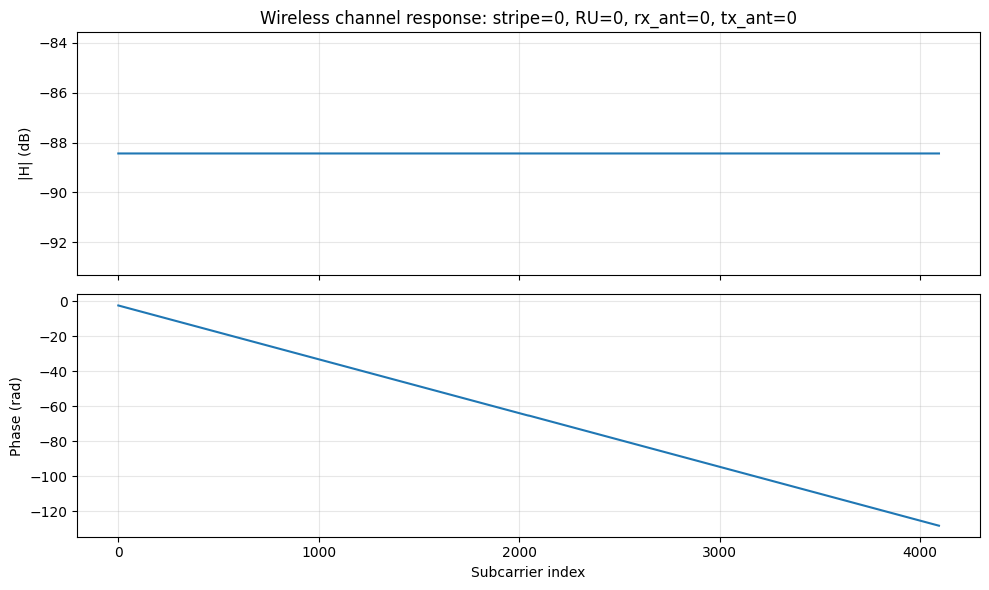

In [71]:
# Transmit the data towards the stripe. We only perform this task once. Every UE in the room will transmit the same
# signal towards the stripe. Only its position and hence the channel will change.

ue_beam = 0 # beam angle of zero
ue_shift = ue_ru.phase_shifter.get_phases(ue_beam)
iq_data_tx, imdata = ue_ru.transmit(ofdm_time_after_ue, ue_shift)

# Construct the wireless channel for this UE.
ue_pos = config["ue_positions"][0]
print(f'ue_pos: {ue_pos}')

# Legacy path still works: channel = Channel.from_sionna(ue_pos, environment, debug=True)
channel = build_channel(
    channel_model=channel_model,
    ue_coordinates=ue_pos,
    sim_env=environment,
    component_config=component_config,
    stripe_positions=config["radio_stripes"],
    waveform=wf,
    Nr_ue_antennas=config["antenna"]["N_antennas"],
    Nr_ru_antennas=config["antenna"]["N_antennas"],
    debug=False,
    los_normalize_gain=los_normalize_gain,
)

if plot_wireless_channel:
    csi_plot = channel.get_csi(plot_channel_stripe_idx, plot_channel_ru_idx)
    h_plot = csi_plot[plot_channel_rx_ant_idx, plot_channel_tx_ant_idx, :]
    subcarrier_idx = np.arange(h_plot.shape[0])

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    axes[0].plot(subcarrier_idx, 20 * np.log10(np.abs(h_plot) + 1e-12))
    axes[0].set_ylabel("|H| (dB)")
    axes[0].set_title(
        f"Wireless channel response: stripe={plot_channel_stripe_idx}, RU={plot_channel_ru_idx}, "
        f"rx_ant={plot_channel_rx_ant_idx}, tx_ant={plot_channel_tx_ant_idx}"
    )
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(subcarrier_idx, np.unwrap(np.angle(h_plot)))
    axes[1].set_xlabel("Subcarrier index")
    axes[1].set_ylabel("Phase (rad)")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Transmit the data over the channel and get the data at all the radio units.
active_stripe_idx = 0
active_ru_idx = 0
iq_data_rx = channel.transmit_ul_id(iq_data_tx, active_stripe_idx, active_ru_idx, wf)

full data shape (4, 2, 16584)
data shape at RU 0 of stripe 0: (4, 2, 16584)
ru shift: [0. 0. 0. 0.]


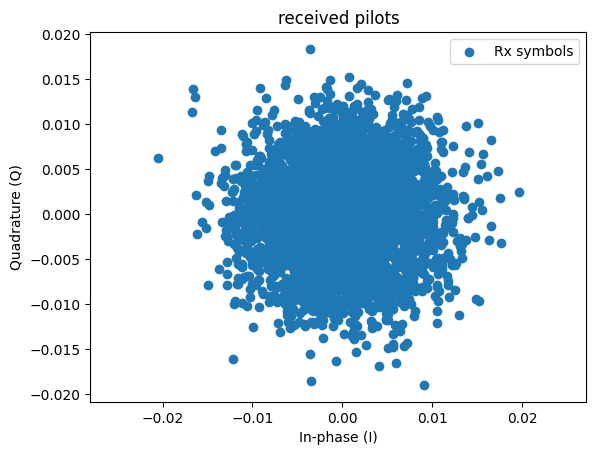

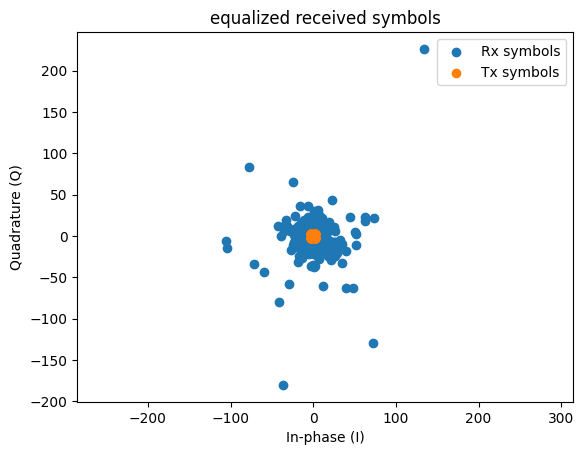

In [72]:
# Receive the data over the stripe coming from the active radio unit (ru_idx).
stripe = stripes[active_stripe_idx]
stripe.active_unit = active_ru_idx
print(f'full data shape {iq_data_rx.shape}')
print(f'data shape at RU {active_ru_idx} of stripe {active_stripe_idx}: {iq_data_rx.shape}')
ru_beam = 0 # beam angle of zero
ru_shift = stripe.radio_units[0].phase_shifter.get_phases(ru_beam)
print(f'ru shift: {ru_shift}')
y, imdata = stripe.receive(iq_data_rx, ru_shift)

y_combined_freq = wf.ofdm_time_to_freq(y)

# plot received pilots
rx_subc = wf.extract_subcarriers(y_combined_freq)
wf.plot_constellation(rx_subc[0, wf.pilot_indices], title="received pilots")

# channel estimation
subc = wf.extract_subcarriers(y_combined_freq)
ls_interp_mode = "phase" if channel_model == "los" else "cartesian"
H_est = wf.channel_estimate_ls(subc, interp_mode=ls_interp_mode)

# equalization
eq_subc = wf.equalize_one_tap(subc, H_est)

# plot equalized constellation
wf.plot_constellation(eq_subc, symbols_tx=xsubc, title="equalized received symbols")

# Demap data carriers and rebuild stream
y_qam = wf.demap_data_from_grid(eq_subc).flatten()  # these are the received QAM symbols

# quick sanity
assert y_qam.shape[0] == qam.shape[0], f"Lengths differ: rx {y_qam.shape[0]} tx {qam.shape[0]}"

y_bits = wf.qam_to_bits(y_qam)

ber = wf.compute_ber(bits, y_bits)

nmse = np.sum(np.abs(eq_subc - xsubc) ** 2) / np.sum(np.abs(xsubc) ** 2)
nmse = 10 * np.log10(nmse)

